# Lecture 4 — Line Opacity I: A Single Line

*Stellar Spectroscopy from Scratch — tensor-native stellar spectroscopy, validated against reference calculations*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*This lecture builds the **Voigt function** and the single-line opacity in clean **`torch`** that runs on the GPU (Apple **MPS** or **CUDA**, with a CPU fallback in fp64). The lecture's new pedagogy is the **vectorization**: how Kurucz's branchy, per-point Voigt routine becomes a single **branchless** tensor expression evaluated on the whole $(a, v)$ grid at once. It ends with a **comparison cell** that validates the Voigt and line opacity against `reference/L4.npz` to the documented float floor. The clean torch implementation is a pedagogical reduction of the production `kgpu` engine's `harris_hav` kernel — the notebook imports neither `kgpu` nor pykurucz.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Write the **line absorption coefficient** and explain every factor: the classical constant, the **oscillator strength** behind `log gf`, and the lower-level population.
- Use the **Boltzmann** factor and the **excitation potential** $\chi_\ell$ to populate the lower level of a transition.
- Build the **Doppler core** from thermal motion and microturbulence, and the **Lorentzian wings** from natural, Stark, and van der Waals broadening.
- Combine the two into the **Voigt profile** — the real part of the Faddeeva function — and reproduce Kurucz's Harris-table approximation, the form the reference uses.
- Recast Kurucz's **three-branch, per-point** Voigt routine as a single **branchless** `torch` expression that evaluates the whole damping × frequency grid at once — every regime computed, the right one selected by `torch.where` — and see why that is the GPU-native shape.
- **Validate** the Voigt and line opacity against the NumPy reference to the float floor (fp32 GPU $\leftrightarrow$ fp64 NumPy).

## Introduction

The continuum of Lecture 3 is the smooth canvas; a spectral **line** comes from a bound-bound transition, where a bound electron jumps between two specific energy levels. The transition has a single rest frequency, but broadening spreads the extra opacity over a band of nearby frequencies. In an LTE photosphere with temperature decreasing outward, that added opacity shifts the effective formation height upward to cooler, dimmer layers, so the feature appears in absorption. Two questions define a line. *How strong is it* — how much opacity does it add at line centre? And *what shape* does it have — how is that opacity spread over wavelength?

The strength is set by the transition's **oscillator strength** and the number of atoms in the lower level; the shape, by the **Voigt profile**, the convolution of a thermal Doppler core with pressure-broadened Lorentzian wings. The Voigt routine the reference uses — Kurucz's Harris-table approximation — is written as a chain of `if/elif/else` branches that each handle a different damping regime, and inside the intermediate regime it splits *per point* on the value of $a + |v|$. That is natural on a CPU walking one $v$ at a time. On the GPU it is the wrong shape: a data-dependent branch forces lanes to diverge. So our job here is to **flatten** it — compute *all three* regimes for *every* $(a, v)$ at once and select the right one with a boolean mask. That is the lecture's added lesson, and the structure the production `kgpu` engine uses.

**Setup — the device and the precision budget.** We pick the compute device once: **MPS** on Apple Silicon, **CUDA** on an NVIDIA box, otherwise **CPU**. MPS lacks practical float64 support, and this teaching path deliberately uses **fp32** on both MPS and CUDA so the accelerator route has one uniform precision budget; CUDA hardware can support float64, but that is not the default path here. On the GPU the parity bar is therefore the documented float floor (~$10^{-6}$ for the Voigt and the line opacity); on CPU we use **fp64** and recover machine precision. We carry NumPy and Matplotlib alongside `torch` — NumPy holds the reference values we validate against, and the comparison at the end is done in NumPy.

In [1]:
import pathlib, math
import numpy as np
import torch
import matplotlib.pyplot as plt

# pick the compute device ONCE; MPS (Apple) -> CUDA -> CPU. The accelerator teaching
# path uses fp32 on both MPS and CUDA, so its parity bar is the documented float floor;
# on CPU we use fp64 and recover machine precision.
if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64

def dev(x):
    """Move an array/tensor onto the compute device in the working dtype. Pass tensors through
    on-device (never np.asarray an MPS tensor — that raises); only host arrays are wrapped."""
    if torch.is_tensor(x):
        return x.to(device=DEVICE, dtype=DTYPE)
    return torch.as_tensor(np.asarray(x), dtype=DTYPE, device=DEVICE)

print(f"device = {DEVICE.type}   working dtype = {str(DTYPE).split('.')[-1]}")

plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

device = mps   working dtype = float32


Load the reference bundle, `reference/L4.npz`. It carries the precomputed pykurucz Voigt grid (`v`, `a`, `H`), the three Harris special-function tables (`h0tab`, `h1tab`, `h2tab`), the atmospheric structure from Lectures 1–2 (`T`, `tk`, `xne`, `rho`, `nHI`), and the iron data (`n_FeI`, `U_FeI`). We define one helper, `compare`, that moves a GPU tensor back to NumPy and reports the maximum relative deviation from the reference — the per-part check used throughout the course.

In [2]:
REF = np.load(pathlib.Path("..") / "reference" / "L4.npz")

def compare(name, ours, ref, tol=1e-6):
    """Report how closely a GPU result matches the NumPy reference (the per-part check)."""
    # bring the GPU tensor back to NumPy/fp64 (move to CPU FIRST, then cast: MPS has no float64)
    if torch.is_tensor(ours):
        ours = ours.detach().cpu().to(torch.float64).numpy()
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)
    denom = np.where(ref != 0.0, np.abs(ref), 1.0)
    rel = float(np.max(np.abs(ours - ref) / denom))
    tag = "exact" if rel < 1e-12 else ("agree" if rel < tol else "CHECK")
    print(f"{name:28s}  max|rel diff| = {rel:.2e}   [{tag}]")
    return rel

# Physical constants in CGS (Planck h, speed of light c, Boltzmann k).
H_C, C, K = 6.62607015e-27, 2.99792458e10, 1.380649e-16
AMU = 1.66053907e-24
print("reference loaded:", ", ".join(REF.files))

reference loaded: v, a, H, T, tk, xne, rho, nHI, n_FeI, U_FeI, tau, h0tab, h1tab, h2tab


## The strength of a line

The monochromatic absorption coefficient of a bound-bound transition, per unit volume, is

$$
\alpha_\nu = \frac{\pi e^2}{m_e c}\, f_{\ell u}\, n_\ell\, \phi(\nu)\,\big(1 - e^{-h\nu/kT}\big)\quad[\mathrm{cm^{-1}}],
$$

a product of four pieces. The classical constant $\pi e^2/m_e c = 0.02654\ \mathrm{cm^2\,Hz}$ is the cross-section a classical oscillator would present, integrated over frequency. The **oscillator strength** $f_{\ell u}$ corrects that classical value for the real transition; the **lower-level population** $n_\ell$ counts the available absorbers; $\phi(\nu)$ is the line profile, normalised to $\int\phi\,d\nu = 1$; and the last factor is the stimulated-emission correction $(1 - e^{-h\nu/kT})$ from Lecture 1.

Line lists give **$\log gf$** — the base-ten log of the oscillator strength times the lower level's statistical weight $g_\ell$ — because the opacity uses $f_{\ell u}\,n_\ell = gf \cdot (n_\ell/g_\ell)$, and $n_\ell/g_\ell$ is exactly what the Boltzmann factor gives. This whole expression is elementwise, so on the GPU it is one tensor multiply; nothing here needs care beyond carrying the constant. We evaluate the classical constant now and assemble the rest once we have the profile.

In [3]:
# Classical line constant pi e^2 / (m_e c), from the electron charge and mass in CGS.
CLASSICAL = math.pi * (4.803204e-10)**2 / (9.1093837e-28 * C)    # [cm^2 Hz]
print(f"classical line constant  pi e^2 / (m_e c) = {CLASSICAL:.5e} cm^2 Hz")

classical line constant  pi e^2 / (m_e c) = 2.65401e-02 cm^2 Hz


## Populating the lower level

Two factors set how many atoms sit in the lower level, both from Lecture 2. First, what fraction of the element is in the right ionization stage (here neutral iron, Fe I). Second, within that ion, the **Boltzmann** factor places a fraction in the lower level $\ell$ at excitation energy $\chi_\ell$:

$$
\frac{n_\ell}{g_\ell} = \frac{n(\mathrm{Fe\,I})}{U_{\rm Fe\,I}(T)}\,e^{-\chi_\ell/kT}.
$$

The **excitation potential** $\chi_\ell$ is the lever: a ground-state line carries no excitation penalty, while a high-excitation line is populated only in the hotter, deeper layers — the lever that lets spectroscopy measure temperature. We take $n(\mathrm{Fe\,I})$ and $U_{\rm Fe\,I}$ straight from the equation of state, carried in the reference data, and pick the layer nearest $\tau = 2/3$ as the reference depth. (`KEV` is $k_B$ in eV K$^{-1}$, so $\chi_\ell/(k_B T)$ is dimensionless for $\chi_\ell$ in eV.)

In [4]:
# Atmospheric structure from Lectures 1-2 (CGS), moved onto the device as tensors.
temperature = dev(REF["T"])
electron_density = dev(REF["xne"])
mass_density = dev(REF["rho"])
neutral_hydrogen_density = dev(REF["nHI"])
n_FeI = dev(REF["n_FeI"])
U_FeI = dev(REF["U_FeI"])
tau = dev(REF["tau"])

KEV = 1.0/11604.5    # Boltzmann k_B in eV per kelvin (NOT keV)

# Photosphere layer: nearest tau ~ 2/3, the depth the continuum emerges from.
jp = int(torch.argmin(torch.abs(tau - 2/3)))
print(f"at the photosphere (T={float(temperature[jp]):.0f} K): "
      f"n(Fe I) = {float(n_FeI[jp]):.3e} cm^-3, U(Fe I) = {float(U_FeI[jp]):.1f}")

at the photosphere (T=5892 K): n(Fe I) = 1.162e+10 cm^-3, U(Fe I) = 31.3


## The shape: Doppler core and Lorentzian wings

**Thermal motion** (plus a microturbulent velocity $\xi$) Doppler-broadens the line into a **Gaussian** core of $1/e$ half-width

$$
\Delta\nu_D = \frac{\nu_0}{c}\sqrt{\frac{2kT}{m} + \xi^2},
$$

while finite level lifetimes and particle collisions broaden it into a **Lorentzian** with damping rate $\gamma = \gamma_{\rm rad} + \gamma_{\rm Stark} + \gamma_{\rm vdW}$: **natural** broadening (always present), **Stark** ($\propto n_e$), and **van der Waals** ($\propto n_{\rm H}$). Convolving the two gives the **Voigt profile**

$$
\phi(\nu) = \frac{1}{\sqrt{\pi}\,\Delta\nu_D}\,H(a, v),\qquad
v = \frac{\nu - \nu_0}{\Delta\nu_D},\qquad
a = \frac{\gamma}{4\pi\,\Delta\nu_D},
$$

where $v$ measures distance from line centre in Doppler widths and the **damping parameter** $a$ is the ratio of Lorentzian to Doppler width. The dimensionless **Voigt function** $H(a,v)$ is the heart of every line.

![The Voigt profile is the convolution of the full Gaussian (thermal Doppler) profile with the full Lorentzian (natural plus pressure) profile; the result has a Doppler-dominated core and Lorentzian damping wings.](resources/figures/s4_voigt.png)

### From Kurucz's branchy kernel to one branchless tensor expression

$H(a,v)$ is, mathematically, the real part of the **Faddeeva function** $w(z) = e^{-z^2}\mathrm{erfc}(-iz)$ at $z = v + ia$. The reference does not evaluate that directly; it uses Kurucz's fast **Harris-series approximation**, built from three precomputed tables — $H_0(v) = e^{-v^2}$, $H_1(v)$, and $H_2(v) = (1-2v^2)e^{-v^2}$ — sampled every $0.005$ in $v$, with three regimes selected by the damping $a$:

- **weak damping** ($a < 0.2$): the second-order series $H_0 + a H_1 + a^2 H_2$, falling back to a bare Lorentzian wing where $|v| > 10$;
- **strong damping / far wing** ($a > 1.4$, or $a + |v| > 3.2$): an asymptotic Lorentzian form;
- **intermediate**: a polynomial blend.

The scalar reference writes this as `if a < 0.2: ... elif a > 1.4: ... else: ...`, and the intermediate branch *masks per point* on $a + |v| > 3.2$. That control flow is fine on a CPU; on the GPU it is the wrong shape because different lanes may want different branches. **The tensor recasting:** compute *all three* regimes for *every* $(a, v)$ pair, then select with `torch.where`. The cost is extra arithmetic, but the reward is a regular tensor expression with no Python loop and no per-point control-flow branch in the source. We also turn the table lookup `iv = clip(int(|v|·200 + 0.5), 0, 2000)` into a clamped integer **index tensor** and gather all three tables in one `index_select`. This is the exact structure of the production `kgpu` engine's `harris_hav`, reduced to readable form.

We take $a$ as a 1-D tensor of damping values and $v$ as a 1-D tensor of reduced frequencies, and return the whole $H(a_i, v_j)$ **grid** at once — `A` has shape `[na, 1]`, `V` has shape `[1, nv]`, and they broadcast to `[na, nv]`. All three regimes are computed for every $(a,v)$; the `torch.where(vv > 0, ...)` and `torch.where(u > 0, ...)` guards keep the unselected lanes from dividing by zero (compute a safe denominator everywhere, let the mask discard the wrong branch); and the final two nested `torch.where` calls select weak where $a < 0.2$, far-wing where $a > 1.4$ or $a + |v| > 3.2$, intermediate otherwise. The numeric constants are Kurucz's, matched bit-for-bit with the reference.

In [5]:
# Stack the three Harris tables once (one device tensor, one gather instead of three).
HTAB = torch.stack([dev(REF["h0tab"]), dev(REF["h1tab"]), dev(REF["h2tab"])], dim=0)  # [3, 2001]

def voigt_H(a, v):
    """Kurucz's Harris H(a,v) as ONE branchless tensor expression on the whole (a,v) grid.
    a: [na] damping values, v: [nv] reduced frequencies -> returns [na, nv]. All three
    regimes are computed for every (a,v) and selected by torch.where (no per-point branching)."""
    A = dev(a).reshape(-1, 1)            # [na, 1]
    V = dev(v).reshape(1, -1)            # [1, nv]
    av = torch.abs(V); vv = V*V; aa = A*A

    # table gather: nearest index for each |v| (200 = 1/0.005), one index_select over [3, 2001]
    iv = torch.clamp((av*200.0 + 0.5).to(torch.int64), 0, HTAB.shape[1]-1)
    picked = torch.index_select(HTAB, 1, iv.reshape(-1))        # [3, nv]
    h0, h1t, h2t = (picked[k].reshape(iv.shape) for k in range(3))

    # --- branch 1: weak damping a < 0.2 (table series; bare Lorentzian wing for |v|>10) ---
    vv_safe = torch.where(vv > 0.0, vv, torch.ones_like(vv))
    h_low = torch.where(av > 10.0, 0.5642*A/vv_safe, (h2t*A + h1t)*A + h0)

    # --- branch 2: far-wing asymptotic (with the a<=100 correction) ---
    u = (aa + vv)*1.4142
    u_safe = torch.where(u > 0.0, u, torch.ones_like(u))
    val = A*0.79788/u_safe
    aau, vvu, uu = aa/u_safe, vv/u_safe, u_safe*u_safe
    corr = ((((aau - 10.0*vvu)*aau*3.0 + 15.0*vvu*vvu) + 3.0*vv - aa)/uu + 1.0)
    h_high = torch.where(A <= 100.0, corr*val, val)

    # --- branch 3: intermediate polynomial blend (Kurucz's recurrence constants) ---
    h1 = h1t + h0*1.12838
    h2 = h2t + h1*1.12838 - h0
    h3 = (1.0 - h2t)*0.37613 - h1*0.66667*vv + h2*1.12838
    h4 = (3.0*h3 - h1)*0.37613 + h0*0.66667*vv*vv
    polyA = (((h4*A + h3)*A + h2)*A + h1)*A + h0
    polyB = ((-0.122727278*A + 0.532770573)*A - 0.96284325)*A + 0.979895032
    h_mid = polyA*polyB

    far = (A > 1.4) | ((A + av) > 3.2)
    return torch.where(A < 0.2, h_low, torch.where(far, h_high, h_mid))

**The first per-part check.** Evaluate $H(a,v)$ on the reference grid of six damping values $\times$ 481 frequencies in one call, and compare against pykurucz. Then plot the family of profiles on a denser grid.

Voigt H(a,v) grid             max|rel diff| = 7.85e-07   [agree]


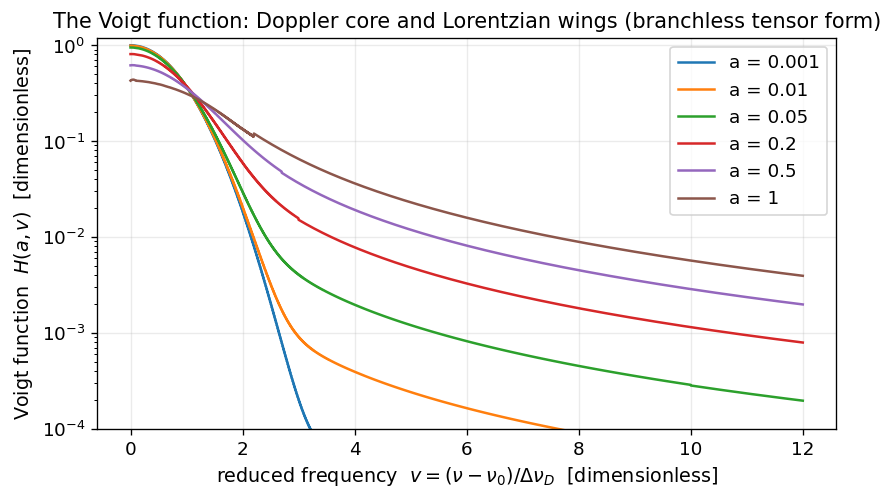

In [6]:
v_ref, a_ref, H_ref = REF["v"], REF["a"], REF["H"]

# One branchless call evaluates the entire 6 x 481 grid at once.
H_grid = voigt_H(a_ref, v_ref)              # [6, 481]
compare("Voigt H(a,v) grid", H_grid, H_ref)

# Plot on a denser v-grid (same routine, every damping value as a row).
v_plot = np.linspace(v_ref.min(), v_ref.max(), 4000)
H_plot = voigt_H(a_ref, v_plot).detach().cpu().to(torch.float64).numpy()
for row, aa in zip(H_plot, a_ref):
    plt.plot(v_plot, row, label=f"a = {aa:g}")
plt.yscale("log"); plt.ylim(1e-4, 1.2)
plt.xlabel(r"reduced frequency  $v = (\nu-\nu_0)/\Delta\nu_D$  [dimensionless]")
plt.ylabel(r"Voigt function  $H(a,v)$  [dimensionless]")
plt.title("The Voigt function: Doppler core and Lorentzian wings (branchless tensor form)")
plt.legend(); plt.tight_layout(); plt.show()

The GPU Voigt reproduces pykurucz to the float floor — and it evaluated the entire $(a,v)$ grid as one broadcasted tensor expression, with no loop over damping values and no per-point branch in the notebook source. PyTorch may still lower that expression to several backend kernels; the pedagogical point is the regular tensor shape. The faint kinks in the $a=0.5$ and $a=1$ curves near $v\approx 2$–$3$ are the seams where Kurucz's piecewise approximation switches between its near-centre and asymptotic-wing branches; the true Voigt is smooth there, but we reproduce the reference exactly, seams and all — and crucially, the `torch.where` selection reproduces those seams identically to the CPU `if/elif/else`, because both pick the same branch by the same threshold.

## Assembling one iron line

Now put it together for a representative neutral-iron line: rest wavelength $\lambda_0 = 500.5\ \mathrm{nm}$, $\log gf = -1.0$, lower-level excitation $\chi_\ell = 3.3\ \mathrm{eV}$, microturbulence $\xi = 2\ \mathrm{km\,s^{-1}}$. The Stark and van der Waals coefficients here are deliberately simple order-of-magnitude **placeholders** for one demonstration line; real synthesis uses transition-specific constants (Lecture 5).

Because this is a single line at a single depth, the Doppler width, the damping $a$, and the strength prefactor are all **scalars** — there is no depth or line axis to batch over yet (that is Lecture 5's million-line forest). The genuinely vectorized work here is the **profile**: the 800-point wavelength grid runs through the branchless `voigt_H` in one call. We compute the scalar shape parameters first.

In [7]:
# Representative neutral-iron line (demonstration values).
lam0_nm = 500.5; loggf = -1.0; chi_l = 3.3
m_Fe = 55.845 * AMU              # iron atom mass [g]
xi = 2.0e5                       # microturbulence [cm/s]
nu0 = C / (lam0_nm * 1e-7)       # line-centre frequency [Hz]

# Doppler width (Gaussian 1/e half-width) at the photosphere layer jp.
dnu_D = (nu0 / C) * torch.sqrt(2*K*temperature[jp]/m_Fe + xi**2)    # [Hz]

# The three broadening channels (rates), summed; Stark/vdW coefficients are toy placeholders.
gamma = 2.0e8 + 1.0e-7*neutral_hydrogen_density[jp] + 1.0e-8*electron_density[jp]  # [s^-1]
a_damp = gamma / (4*math.pi*dnu_D)                        # damping parameter (Lorentzian/Doppler)
print(f"Doppler width = {float(dnu_D):.3e} Hz;  damping a = {float(a_damp):.3f}")

Doppler width = 4.793e+09 Hz;  damping a = 0.042


**A precision trap, and the fix.** The reduced frequency is $v = (\nu - \nu_0)/\Delta\nu_D$. Here $\nu \approx \nu_0 \approx 6\times10^{14}\ \mathrm{Hz}$, but their *difference* across the line is only $\sim5\times10^{10}\ \mathrm{Hz}$ — four orders of magnitude smaller. In **fp32** (≈7 significant digits) that subtraction is **catastrophic cancellation**: it loses ~4 digits, giving a *12%* error in $v$ and wrecking the profile. This is the one place in the lecture where the default fp32 budget is not enough. The bible's rule (§2.4) is to **fp64-promote just that reduction**: we form the small difference $\nu - \nu_0$ in fp64 on the host (where this scalar grid is tiny and cheap), then move the well-conditioned $v$ onto the device for the Voigt. Everything else stays fp32 on the GPU.

Then the full absorption coefficient: the classical constant times $10^{\log gf}$ (strength), the Boltzmann population, the **branchless Voigt** profile (shape), and the stimulated-emission factor; dividing by the mass density gives the opacity per gram. The Voigt call passes `a_damp` as a one-element tensor, so it slots into the same grid kernel.

In [8]:
# Wavelength grid +-0.04 nm around line centre. Form the reduced frequency v = (nu-nu0)/dnu_D
# in fp64 on the host: nu and nu0 are ~6e14 Hz but differ by only ~5e10, so the subtraction is
# catastrophic cancellation in fp32 (~12% error). fp64-promote JUST this tiny scalar reduction
# (bible 2.4), then move the conditioned v onto the device for the GPU Voigt.
lam_np = np.linspace(lam0_nm-0.04, lam0_nm+0.04, 800)         # host fp64
nu_np = C / (lam_np*1e-7)
v = dev((nu_np - float(nu0)) / float(dnu_D))                 # conditioned, then -> device
nu = dev(nu_np)

# Normalised Voigt profile (one branchless call; a_damp as a 1-element tensor -> grid [1, 800]).
phi = voigt_H(a_damp.reshape(1), v)[0] / (math.sqrt(math.pi) * dnu_D)    # [s]

stimulated_emission_factor = 1.0 - torch.exp(-H_C*nu/(K*temperature[jp]))  # Lecture 1
nl_over_gl = (n_FeI[jp]/U_FeI[jp]) * torch.exp(-chi_l/(KEV*temperature[jp]))  # Boltzmann (Lecture 2)

alpha_line = CLASSICAL * 10**loggf * nl_over_gl * phi * stimulated_emission_factor  # [cm^-1]
kappa_line = alpha_line / mass_density[jp]                                           # [cm^2/g]
print(f"line-centre opacity / continuum = {float(kappa_line.max())/0.027:.1f}  (continuum ~0.027 cm^2/g)")

line-centre opacity / continuum = 115.4  (continuum ~0.027 cm^2/g)


Plot the line opacity stacked on a representative H$^-$ continuum ($\sim0.027\ \mathrm{cm^2/g}$) — the spike that carves the absorption feature.

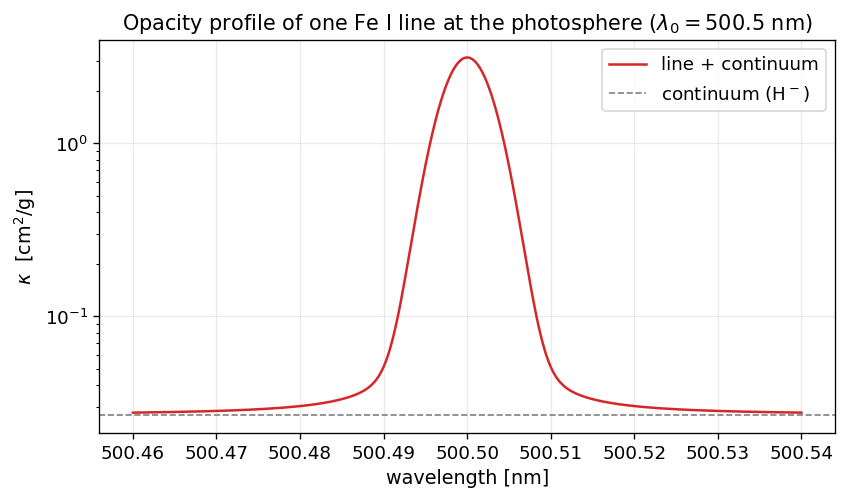

In [9]:
kappa_np = kappa_line.detach().cpu().to(torch.float64).numpy()
plt.plot(lam_np, kappa_np + 0.027, color="C3", label="line + continuum")
plt.axhline(0.027, ls="--", color="0.5", lw=1, label="continuum (H$^-$)")
plt.yscale("log"); plt.xlabel("wavelength [nm]"); plt.ylabel(r"$\kappa$  [cm$^2$/g]")
plt.title(r"Opacity profile of one Fe I line at the photosphere ($\lambda_0=500.5$ nm)")
plt.legend(); plt.tight_layout(); plt.show()

The line raises the opacity more than a hundredfold at its centre, falling through a Gaussian core into Lorentzian wings that merge back into the continuum a fraction of an ångström away. The levers are exposed: $\log gf$ and the Boltzmann factor scale the whole profile, while the damping $a$ controls how much of the line lives in the wings. Vary $\log gf$ (or the abundance hidden in $n(\mathrm{Fe\,I})$) and you trace the **curve of growth**.

## The comparison cell — validating the tensor result against the reference

This is the per-part check used throughout the book. We put **every** tensor result the lecture produced — the Voigt grid and the assembled single-line opacity — next to the NumPy reference (the gold standard, proven bit-for-bit against pykurucz) and report the **maximum relative deviation**, asserting it is below the documented float floor. If this passes, the implementation is correct relative to that reference.

In [10]:
print(f"Validating the GPU line opacity against reference/L4.npz")
print(f"  device = {DEVICE.type}   dtype = {str(DTYPE).split('.')[-1]}\n")

is_fp32 = (DTYPE == torch.float32)
floor = 1e-6 if is_fp32 else 1e-10        # ~1e-6 fp32 on MPS; machine precision in fp64 on CPU

def voigt_H_numpy(a, v):
    """Independent NumPy Harris-table reference for H(a,v), separate from the torch validation path."""
    aa = np.asarray(a, dtype=np.float64).reshape(-1, 1)
    vv0 = np.asarray(v, dtype=np.float64).reshape(1, -1)
    av = np.abs(vv0); vv = vv0*vv0; a2 = aa*aa
    iv = np.clip((av*200.0 + 0.5).astype(np.int64), 0, REF["h0tab"].shape[0]-1)
    h0 = REF["h0tab"][iv]; h1t = REF["h1tab"][iv]; h2t = REF["h2tab"][iv]

    vv_safe = np.where(vv > 0.0, vv, 1.0)
    h_low = np.where(av > 10.0, 0.5642*aa/vv_safe, (h2t*aa + h1t)*aa + h0)

    u = (a2 + vv)*1.4142
    u_safe = np.where(u > 0.0, u, 1.0)
    val = aa*0.79788/u_safe
    aau, vvu, uu = a2/u_safe, vv/u_safe, u_safe*u_safe
    corr = ((((aau - 10.0*vvu)*aau*3.0 + 15.0*vvu*vvu) + 3.0*vv - a2)/uu + 1.0)
    h_high = np.where(aa <= 100.0, corr*val, val)

    h1 = h1t + h0*1.12838
    h2 = h2t + h1*1.12838 - h0
    h3 = (1.0 - h2t)*0.37613 - h1*0.66667*vv + h2*1.12838
    h4 = (3.0*h3 - h1)*0.37613 + h0*0.66667*vv*vv
    polyA = (((h4*aa + h3)*aa + h2)*aa + h1)*aa + h0
    polyB = ((-0.122727278*aa + 0.532770573)*aa - 0.96284325)*aa + 0.979895032
    h_mid = polyA*polyB

    far = (aa > 1.4) | ((aa + av) > 3.2)
    return np.where(aa < 0.2, h_low, np.where(far, h_high, h_mid))

# rebuild the reference single-line kappa with an independent NumPy Harris assembly
temperature_np = REF["T"]
electron_density_np = REF["xne"]
mass_density_np = REF["rho"]
neutral_hydrogen_density_np = REF["nHI"]
nFe_np, UFe_np, tau_np = REF["n_FeI"], REF["U_FeI"], REF["tau"]
jpn = int(np.argmin(np.abs(tau_np - 2/3)))
dnuD = (nu0/C)*np.sqrt(2*K*temperature_np[jpn]/m_Fe + xi**2)
ad = (2.0e8 + 1.0e-7*neutral_hydrogen_density_np[jpn]
      + 1.0e-8*electron_density_np[jpn]) / (4*np.pi*dnuD)
lamn = np.linspace(lam0_nm-0.04, lam0_nm+0.04, 800); nun = C/(lamn*1e-7); vn = (nun-nu0)/dnuD
Hn = voigt_H_numpy(np.array([ad]), vn)[0]
phin = Hn/(np.sqrt(np.pi)*dnuD)
stimulated_emission_factor_np = 1.0 - np.exp(-H_C*nun/(K*temperature_np[jpn]))
nlg = (nFe_np[jpn]/UFe_np[jpn])*np.exp(-chi_l/(KEV*temperature_np[jpn]))
kappa_ref = (CLASSICAL*10**loggf*nlg*phin*stimulated_emission_factor_np)/mass_density_np[jpn]

devs = {
    "Voigt H(a,v) grid":   compare("Voigt H(a,v) grid", H_grid, H_ref, tol=floor),
    "single Fe I line kappa": compare("single Fe I line kappa", kappa_line, kappa_ref, tol=floor),
}
max_dev = max(devs.values())
print(f"\nmax relative deviation (GPU {DEVICE.type}/{str(DTYPE).split('.')[-1]} vs NumPy reference) = {max_dev:.3e}")
status = "PASS" if max_dev < floor else "CHECK"
print(f"documented float floor = {floor:.1e}   ->   [{status}]")
assert max_dev < floor, f"GPU line opacity deviates by {max_dev:.2e}, above the float floor {floor:.1e}"
print("\nThe Voigt and single-line opacity match the NumPy reference to the documented float floor.")

Validating the GPU line opacity against reference/L4.npz
  device = mps   dtype = float32

Voigt H(a,v) grid             max|rel diff| = 7.85e-07   [agree]
single Fe I line kappa        max|rel diff| = 4.66e-07   [agree]

max relative deviation (GPU mps/float32 vs NumPy reference) = 7.850e-07
documented float floor = 1.0e-06   ->   [PASS]

The Voigt and single-line opacity match the NumPy reference to the documented float floor.


**What the number means.** The Voigt function and the single-line opacity reproduce the NumPy reference to the float floor — a few $\times 10^{-6}$ in fp32 on the GPU, machine precision in fp64 on a CPU run. That residual is single-precision round-off of the Harris series and the profile multiply, *not* a physics difference: the formulas, the constants, the Harris tables, and the branch thresholds match the reference. The branchless `torch.where` selection picks the same regime as the CPU `if/elif/else` at every $(a,v)$, so even the piecewise seams match.

**The vectorization lesson.** Kurucz's Voigt routine was written as data-dependent control flow — natural for a CPU walking one frequency at a time. We flattened it: *compute every branch, select with a mask*. That trades extra arithmetic for a regular broadcasted expression with no table-lookup loop in Python. The same move — branch $\to$ mask, loop $\to$ gather — is what turns the next lecture's **million-line forest** from a Python loop into a batched scatter. This single-line example is the kernel of the idea; Lecture 5 reuses exactly this `voigt_H` across every line in the Kurucz list at every depth, on the GPU.

## Summary

- The line absorption coefficient is $\alpha_\nu = (\pi e^2/m_e c)\,f_{\ell u}\,n_\ell\,\phi(\nu)\,(1-e^{-h\nu/kT})$, with $\pi e^2/m_e c = 0.02654\ \mathrm{cm^2\,Hz}$ — an elementwise tensor product on the GPU.
- Line lists give **$\log gf$**; the opacity uses $gf\cdot(n_\ell/g_\ell)$ with $n_\ell/g_\ell = (n_{\rm ion}/U)\,e^{-\chi_\ell/kT}$ from Boltzmann.
- The profile is a **Voigt** $\phi = H(a,v)/(\sqrt{\pi}\Delta\nu_D)$, the convolution of the Gaussian Doppler core with the Lorentzian damping wings, with $a=\gamma/4\pi\Delta\nu_D$.
- $H(a,v)$ is Kurucz's three-branch Harris-table approximation, recast as **one branchless `torch` expression** evaluated on the whole $(a,v)$ grid: every regime computed, the right one selected by `torch.where`; the table lookup is a clamped `index_select`.
- The GPU result matches the NumPy reference to the float floor — the branch-to-mask flattening is exact, seams and all — and the `voigt_H` kernel is reused across the entire line list in Lecture 5.

## Synthesis: what you built and where it goes

You built a single spectral line from its parts. Its **strength** is the classical constant times the oscillator strength `log gf` times the lower-level population — and that population comes from the **ionization** (Saha) and **excitation** (Boltzmann, through $\chi_\ell$) of Lecture 2. Its **shape** is the **Voigt profile**, reproduced here through Kurucz's Harris-table approximation: the convolution of the thermal-plus-turbulent Gaussian Doppler profile with the Lorentzian damping profile from natural, Stark, and van der Waals broadening. You overlaid the result on the H$^-$ continuum and saw the opacity spike that becomes an absorption line.

One line is a demonstration; a real spectrum is a forest. Lecture 5 reads the Kurucz line list — over a million atomic transitions — assigns each its $\log gf$, excitation potential, and damping constants, and sums their Voigt profiles onto a wavelength grid to build the total line opacity at every depth, ready for radiative transfer.

## Practice exercises

**1. Excitation potential and depth.** Recompute the line's central opacity for $\chi_\ell = 0$ and $\chi_\ell = 5\ \mathrm{eV}$ at three depths. Which line is relatively stronger in the cool upper photosphere, and why does high excitation make a line a deeper-forming, more temperature-sensitive probe?

**2. The damping wings.** Increase $\gamma_{\rm vdW}$ by factors of $3$ and $10$ and plot the profiles. How does the damping parameter $a$ change, and where in the profile does the extra opacity appear? This is the surface-gravity diagnostic.

**3. Toy equivalent-width proxy.** Numerically integrate the line depth $1 - e^{-\tau_{\rm line}}$ over wavelength across the line for a range of $\log gf$ from $-4$ to $0$, treating $\tau_{\rm line} = \kappa_{\rm line}/\kappa_{\rm cont}$ with a fixed normalisation. This is not formal radiative transfer, so what matters is the curve's shape: the linear, saturated, and damping-wing regimes of the curve of growth.

## Further reading

- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed.** Chapters 11–13 on line absorption coefficients, broadening, and the curve of growth.
- **Rutten, R. J. (2003). *Radiative Transfer in Stellar Atmospheres*.** A lucid derivation of the Voigt profile and line opacity.
- **Humlíček, J. (1982). *Optimized computation of the Voigt and complex probability functions*, JQSRT, 27, 437.** Fast accurate evaluation of the Faddeeva function behind the Voigt profile.
- **Anstee, S. D. & O'Mara, B. J. (1995). *Width cross-sections for collisional broadening...*, MNRAS, 276, 859.** Modern van der Waals broadening theory.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference Harris-Voigt tables are computed with.